# K-Means Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

C:\Users\user\AppData\Local\Temp\ipykernel_14904\2114013163.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Importing the dataset

In [2]:
df = pd.read_csv('https://drive.google.com/u/1/uc?id=1IcUAqkH50H1qXg8rPySSzDsOBgsuMRxJ&export=download')

In [5]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [4]:
from sklearn.manifold import TSNE

In [10]:
transformer = TSNE()
transformed_array= transformer.fit_transform(df[['Age','Annual Income (k$)','Spending Score (1-100)']])

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


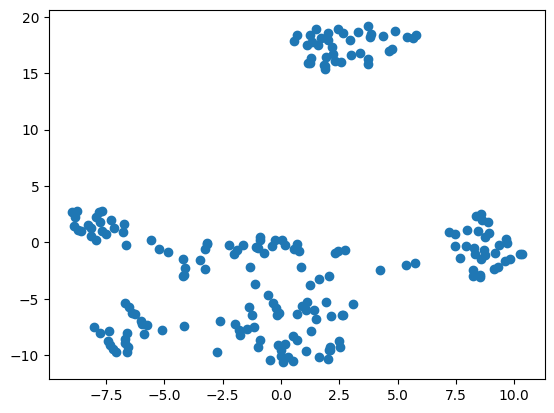

In [11]:
plt.scatter(x=transformed_array[:,0], y=transformed_array[:,1])

#### create a new variable `X` that contains the values of column: `Annual Income (k$)` and `Spending Score (1-100)`.

In [13]:
X = df[['Annual Income (k$)','Spending Score (1-100)']].values

X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

## Standardise the Data

In [14]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler(with_mean=False)

# Fit the scaler to your data and transform it
X_standardized = scaler.fit_transform(X)

In [15]:
X_standardized

array([[0.57254144, 1.51404087],
       [0.57254144, 3.14454642],
       [0.61071087, 0.23292936],
       [0.61071087, 2.98926017],
       [0.6488803 , 1.55286243],
       [0.6488803 , 2.95043861],
       [0.68704973, 0.23292936],
       [0.68704973, 3.64922671],
       [0.72521915, 0.11646468],
       [0.72521915, 2.79515237],
       [0.72521915, 0.54350185],
       [0.72521915, 3.84333451],
       [0.76338858, 0.58232341],
       [0.76338858, 2.98926017],
       [0.76338858, 0.50468029],
       [0.76338858, 3.0669033 ],
       [0.80155801, 1.35875462],
       [0.80155801, 2.56222301],
       [0.87789687, 1.12582526],
       [0.87789687, 3.80451295],
       [0.9160663 , 1.35875462],
       [0.9160663 , 2.83397393],
       [0.95423573, 0.1941078 ],
       [0.95423573, 2.83397393],
       [1.06874402, 0.54350185],
       [1.06874402, 3.18336798],
       [1.06874402, 1.24228994],
       [1.06874402, 2.3681152 ],
       [1.10691345, 1.20346838],
       [1.10691345, 3.37747578],
       [1.

## Using the elbow method to find the optimal number of clusters

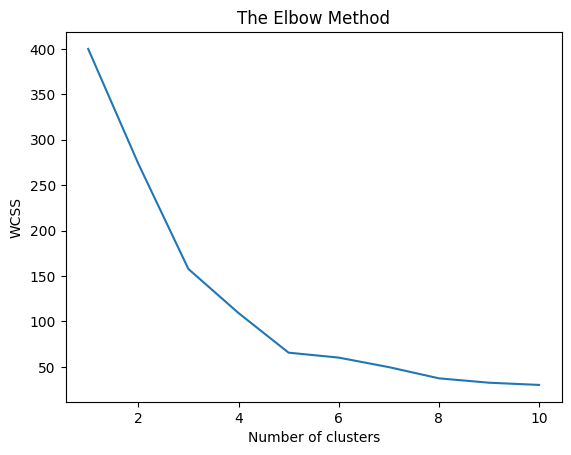

In [16]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_standardized)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()



## Training the K-Means model on the dataset

In [18]:
kmeans = KMeans(n_clusters = 3, random_state = 0)
y_kmeans = kmeans.fit_predict(X_standardized)

## Visualising the clusters

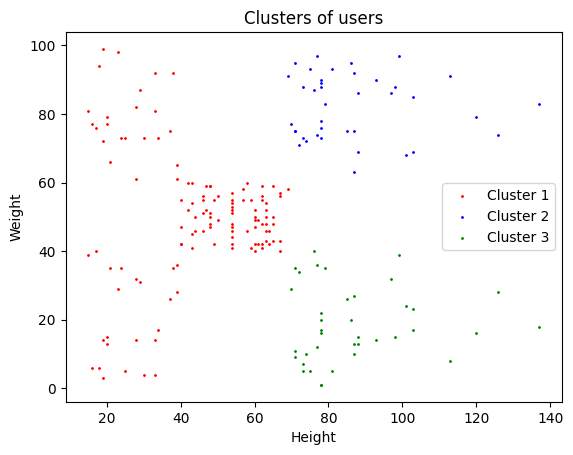

In [19]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 1, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 1, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 1, c = 'green', label = 'Cluster 3')
plt.title('Clusters of users')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()